# pyda YData testing

Test script to show some examples uses of pyda YData objects

In [16]:
import os
import sys

import numpy as np

import pyda

sys.path.insert(0, os.path.abspath('../'))

from pyda import *

# from pyda.ydata import YData
# from pyda.tsdata import TSData
from pyda.dsp.spectral import psd
import numpy

## Setup matplotlib

In [17]:
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (15, 10),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

## Create YData object

In [18]:
y1 = YData.randn(ndata=10, name="myy", yunits="m")

print(y1)

-------- YData ---------
  name: myy
  uuid: 7c5ccb79-71b8-41f6-aae5-cb233c1c6516
 yaxis: Y-Values=(10,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------
-------- YData ---------
  name: myy
  uuid: 59de0181-bc35-4dc3-8079-134cbcb050af
 yaxis: Y-Values=(10,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------


## Create single value

In [19]:

y2 = YData(yaxis=2, yunits="V")
print(y2)

-------- YData ---------
  name: YData
  uuid: 928b8d6f-c1c1-4f96-8ee9-0644a383309e
 yaxis: Y-Values=(1,)[V]
    dy: Y-Values=(1,)[V]

-----------------------------
-------- YData ---------
  name: YData
  uuid: 1f9766a4-20c0-4349-9213-06d9a4e95d8c
 yaxis: Y-Values=(1,)[V]
    dy: Y-Values=(1,)[V]

-----------------------------


## Create from list

In [20]:
y3 = YData(yaxis=[1,2,3], yunits='m', name='list')
print(y3)

-------- YData ---------
  name: list
  uuid: 4952fbf6-bf74-4ca2-9695-b52c938e4bf7
 yaxis: Y-Values=(3,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------
-------- YData ---------
  name: list
  uuid: 55bd13d0-e0e8-462c-b62b-022313d54731
 yaxis: Y-Values=(3,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------


In [21]:
y4 = y1 * y2
print(y4)

-------- YData ---------
  name: (myy*YData)
  uuid: 7c5ccb79-71b8-41f6-aae5-cb233c1c6516
 yaxis: Y-Values=(10,)[m][V]
    dy: Y-Values=(10,)[m][V]

-----------------------------
-------- YData ---------
  name: (myy*YData)
  uuid: 59de0181-bc35-4dc3-8079-134cbcb050af
 yaxis: Y-Values=(10,)[m][V]
    dy: Y-Values=(10,)[m][V]

-----------------------------


In [22]:
print(y1.ydata())
print(y4.ydata())


[-1.93683259  0.22278759  0.15258855  0.41667102 -0.23537826 -1.15384186
  0.31350726 -0.71085691  0.2640157   0.94471246]
[-3.87366518  0.44557519  0.3051771   0.83334204 -0.47075651 -2.30768372
  0.62701452 -1.42171382  0.5280314   1.88942491]
[-1.39593692 -0.12749534 -1.1403295   0.50022358 -0.05255659  0.13814821
  1.97585838 -0.28410421  0.51533847  1.60922823]
[-2.79187385 -0.25499068 -2.28065899  1.00044717 -0.10511319  0.27629641
  3.95171676 -0.56820841  1.03067694  3.21845646]


## Multiply/divide TSData by YData

In [23]:
ts1 = TSData.randn(fs=1, nsecs=10, yunits='m', name='ts')

ts2 = ts1 * y2
ts3 = ts1 / y2
print(ts2)
print(ts3)

-------- TSData ---------
  name: (ts*YData)
  uuid: 883bb9d6-de96-4bc2-a046-da11cca0f307
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m][V]
    dx: Time=(1,)[s]
    dy: Amplitude=(10,)[m][V]

-----------------------------
-------- TSData ---------
  name: ts/YData
  uuid: 883bb9d6-de96-4bc2-a046-da11cca0f307
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m][V^(-1)]
    dx: Time=(1,)[s]
    dy: Amplitude=(10,)[m][V^(-1)]

-----------------------------
-------- TSData ---------
  name: (ts*YData)
  uuid: 8b4b33d7-3a7c-450d-a586-1fb689d6d3e4
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m][V]
    dx: Time=(1,)[s]
    dy: Amplitude=(10,)[m][V]

-----------------------------
-------- TSData ---------
  name: ts/YData
  uuid: 8b4b33d7-3a7c-450d-a586-1fb689d6d3e4
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m][V^(-1)]
    dx: Time=(1,)[s]
    dy: Amplitude=(10,)[m][V^(-1)]

------------------

## Raise to power

In [24]:
ts4 = ts1 ** y2
print(ts4)

-------- TSData ---------
  name: ts**2
  uuid: 883bb9d6-de96-4bc2-a046-da11cca0f307
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m^(2)]
    dx: Time=(1,)[s]
    dy: Amplitude=(10,)[m^(2)]

-----------------------------
-------- TSData ---------
  name: ts**2
  uuid: 8b4b33d7-3a7c-450d-a586-1fb689d6d3e4
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m^(2)]
    dx: Time=(1,)[s]
    dy: Amplitude=(10,)[m^(2)]

-----------------------------


## Add/subtract to/from TSData

In [25]:
y4 = YData(yaxis=3, yunits='m')
ts5 = ts1 + y4
ts6 = ts1 - y4
print(ts5)
print(ts6)

-------- TSData ---------
  name: (ts + YData)
  uuid: 883bb9d6-de96-4bc2-a046-da11cca0f307
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m]
    dx: Time=(1,)[s]
    dy: Amplitude=(1,)[m]

-----------------------------
-------- TSData ---------
  name: (ts - YData)
  uuid: 883bb9d6-de96-4bc2-a046-da11cca0f307
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m]
    dx: Time=(1,)[s]
    dy: Amplitude=(1,)[m]

-----------------------------
-------- TSData ---------
  name: (ts + YData)
  uuid: 8b4b33d7-3a7c-450d-a586-1fb689d6d3e4
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m]
    dx: Time=(1,)[s]
    dy: Amplitude=(1,)[m]

-----------------------------
-------- TSData ---------
  name: (ts - YData)
  uuid: 8b4b33d7-3a7c-450d-a586-1fb689d6d3e4
    fs: 1.0
 nsecs: 10.0
 xaxis: Time=(10,)[s]
 yaxis: Amplitude=(10,)[m]
    dx: Time=(1,)[s]
    dy: Amplitude=(1,)[m]

-----------------------------


[[0.4 0.2 0.5]]


[<Figure size 1500x1000 with 0 Axes>,
 [<Axes: xlabel='Index', ylabel='Y-Values $\\left[\\,{\\mathrm{m}} \\right]$'>],
 [<ErrorbarContainer object of 3 artists>]]

<Figure size 1500x1000 with 0 Axes>

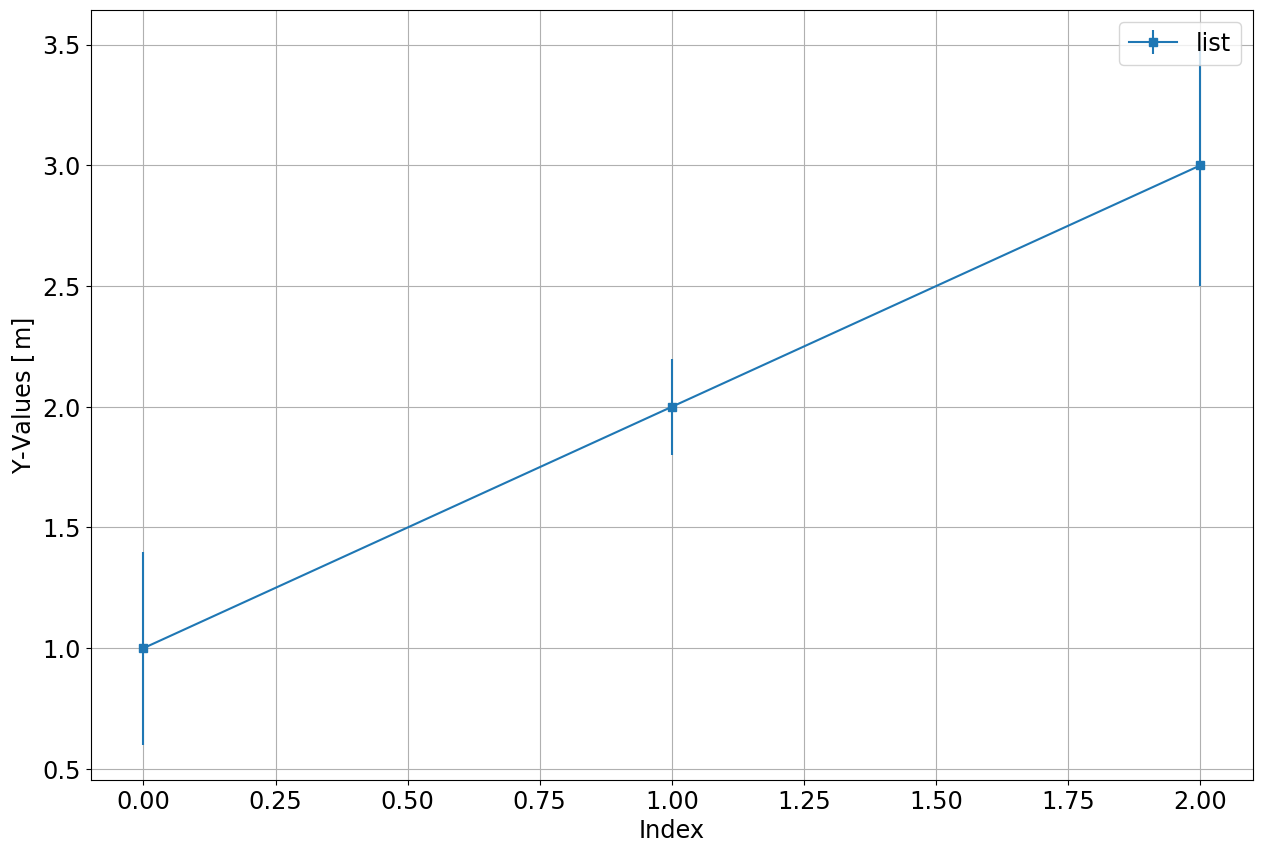

[[0.4 0.2 0.5]]


[<Figure size 1500x1000 with 0 Axes>,
 [<Axes: xlabel='Index', ylabel='Y-Values $\\left[\\,{\\mathrm{m}} \\right]$'>],
 [<ErrorbarContainer object of 3 artists>]]

<Figure size 1500x1000 with 0 Axes>

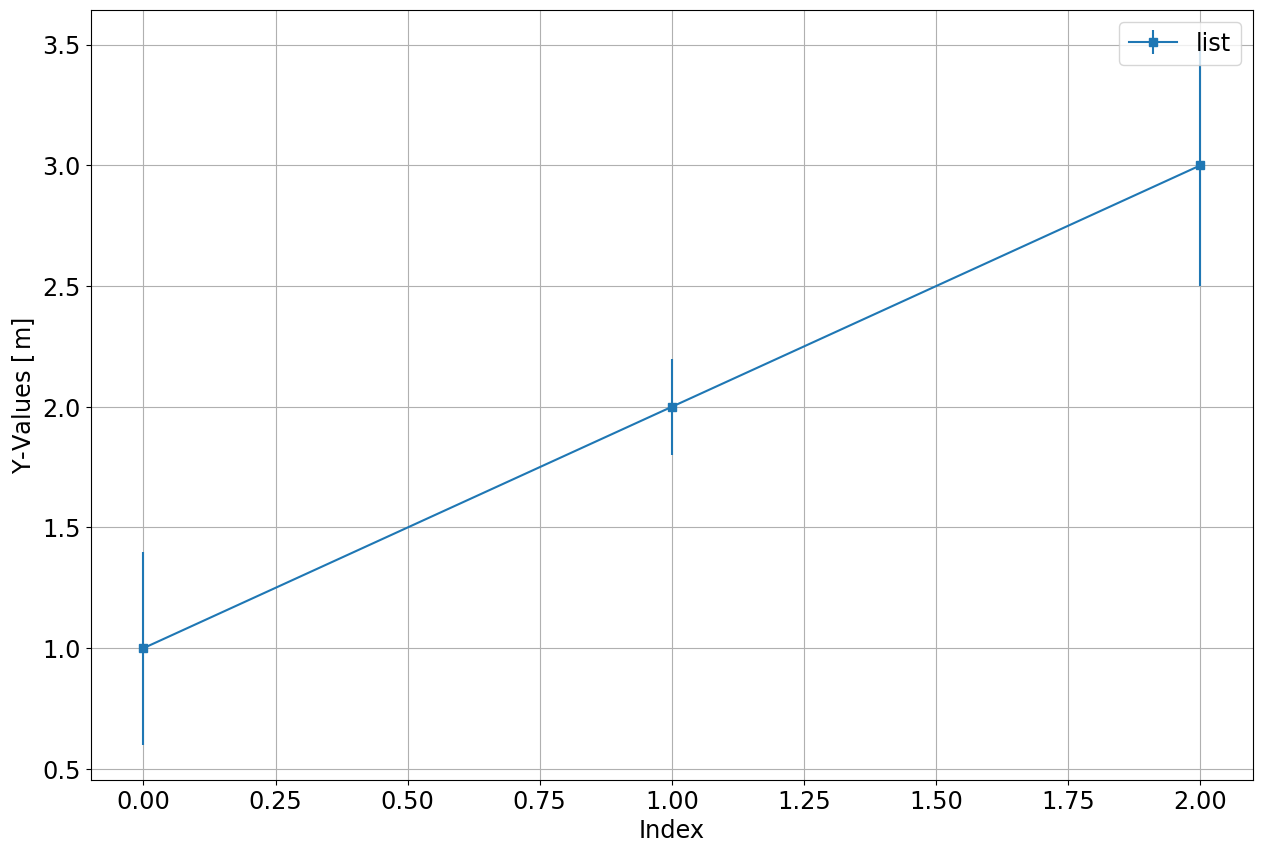

In [26]:

y3.yaxis.ddata =[0.4,0.2,0.5]
y3.marker = 's'
print(y3.yaxis.ddata)
y3.plot(ShowErrors=True)

In [27]:


x = YData(yaxis=2, yunits="m", name="x")
y = YData(yaxis=3.1, yunits="m", name="y")
a = x ** y

print(a)
print(a.ydata())

b = 10 ** y
print(b)
print(b.ydata())

c = y ** 2
print(c)
print(c.ydata())


-------- YData ---------
  name: x**3.1
  uuid: c6522821-f99a-4304-80d2-c759830cdca5
 yaxis: Y-Values=(1,)[m^(31/10)]
    dy: Y-Values=(1,)[m^(31/10)]

-----------------------------
[8.5741877]
-------- YData ---------
  name: 10**y
  uuid: f02a7728-d8e8-4b07-a2ed-a004cadb87aa
 yaxis: Y-Values=(1,)[m^(31/10)]
    dy: Y-Values=(1,)[m^(31/10)]

-----------------------------
[1258.92541179]
-------- YData ---------
  name: y**2
  uuid: f02a7728-d8e8-4b07-a2ed-a004cadb87aa
 yaxis: Y-Values=(1,)[m^(2)]
    dy: Y-Values=(1,)[m^(2)]

-----------------------------
[9.61]
-------- YData ---------
  name: x**3.1
  uuid: 8b460907-b2e6-474b-a96f-a3f4849198a3
 yaxis: Y-Values=(1,)[m^(31/10)]
    dy: Y-Values=(1,)[m^(31/10)]

-----------------------------
[8.5741877]
-------- YData ---------
  name: 10**y
  uuid: e34e6b56-99c2-4733-8a84-ab645731a24e
 yaxis: Y-Values=(1,)[m^(31/10)]
    dy: Y-Values=(1,)[m^(31/10)]

-----------------------------
[1258.92541179]
-------- YData ---------
  name: y**2
 

In [28]:

vals = numpy.array([1,2,3])
x = YData(yaxis=2, yunits="m", name="x")

a = vals ** x.ydata()
print(a)

b = vals ** 2
print(b)


[1 4 9]
[1 4 9]
[1 4 9]
[1 4 9]


In [29]:


vals = numpy.array([1,2,3])
x = YData(yaxis=2, yunits="m", name="x")

b = x * vals
print(b)

vals = numpy.array([1,2,3,4,5,6])
x = YData(yaxis=2, yunits="m", name="x")

b = x * vals
print(b)

-------- YData ---------
  name: (x*ndarray)
  uuid: 19803d5e-fd38-48cb-88e6-7983001d7eac
 yaxis: Y-Values=(3,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------
-------- YData ---------
  name: (x*ndarray)
  uuid: 5a331e52-5439-4cfe-8655-4d45d74b1a9d
 yaxis: Y-Values=(6,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------
-------- YData ---------
  name: (x*ndarray)
  uuid: 9de9e1e7-2a6b-4b36-89de-0a276b634682
 yaxis: Y-Values=(3,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------
-------- YData ---------
  name: (x*ndarray)
  uuid: 0080ae2e-a2f0-4c37-bcc1-5a43a1f0a9e6
 yaxis: Y-Values=(6,)[m]
    dy: Y-Values=(1,)[m]

-----------------------------


In [30]:

# ydata * xydata

x = YData(yaxis=2, yunits="m", name="x")
obj = XYData(xaxis=numpy.arange(1, 101), yaxis=numpy.random.randn(1, 100), name="A")

b = x * obj
c = obj * x
print(b)
print(c)



-------- XYData ---------
  name: (x*A)
  uuid: f9ab8097-f2d2-4214-b858-aa50d276d04c
 xaxis: X-Values=(100,)[]
 yaxis: Y-Values=(100,)[m]
    dx: X-Values=(1,)[]
    dy: Y-Values=(100,)[m]

-----------------------------
-------- XYData ---------
  name: (A*x)
  uuid: f9ab8097-f2d2-4214-b858-aa50d276d04c
 xaxis: X-Values=(100,)[]
 yaxis: Y-Values=(100,)[m]
    dx: X-Values=(1,)[]
    dy: Y-Values=(100,)[m]

-----------------------------
-------- XYData ---------
  name: (x*A)
  uuid: 29f8293e-23b9-4341-aad4-b72fafafeafb
 xaxis: X-Values=(100,)[]
 yaxis: Y-Values=(100,)[m]
    dx: X-Values=(1,)[]
    dy: Y-Values=(100,)[m]

-----------------------------
-------- XYData ---------
  name: (A*x)
  uuid: 29f8293e-23b9-4341-aad4-b72fafafeafb
 xaxis: X-Values=(100,)[]
 yaxis: Y-Values=(100,)[m]
    dx: X-Values=(1,)[]
    dy: Y-Values=(100,)[m]

-----------------------------
